Laboratorio Número 1 - Introducción a la Ciencia de Datos

Montiel Nicolas, Gabriel Lopez.

Lectura de datos
- Se crearon dos DataFrames que contienen los datos contenidos en los archivos .csv

- Como los archivos contienen datos con tildes primero se los tuvo codificar

- Una vez impresos ambos DataFrames se puede observar que las tablas contienen información sobre un seguimiento de ventas

- DataFrame1 con 1000 filas y DataFrame2 con 50

In [3]:
import pandas as pd

dataFrame1 = pd.read_csv('datos_ventas_suc1.csv', encoding='latin-1')
dataFrame2 = pd.read_csv('datos_ventas_suc2.csv', encoding='latin-1')

print(dataFrame1)
print("________________________________________________________________")
print(dataFrame2)

         Fecha     Producto  Cantidad  Precio Unitario  Total Venta
0    1/17/2023  Electrónica         7              200         1400
1     9/1/2023  Electrónica         8              200         1600
2    7/29/2023     Juguetes         3               30           90
3    10/4/2023    Alimentos         4               10           40
4    2/28/2023  Electrónica         6              200         1200
..         ...          ...       ...              ...          ...
995  4/27/2023    Alimentos         2               10           20
996   6/9/2023         Ropa        10               50          500
997  8/21/2023    Alimentos         8               10           80
998  3/28/2023  Electrónica         6              200         1200
999   3/7/2023  Electrónica         4              200          800

[1000 rows x 5 columns]
________________________________________________________________
         Fecha     Producto  Cantidad  Precio Unitario  Total Venta
0    8/25/2023  Electrónic

Fusión de Datos
- Se concatenó DataFrame2 a DataFrame1 juntando los datos de ambas tablas en una sola

- DataFrameFusionado tiene un total de 1050 filas demostrando que la fusión se realizó correctamente

In [4]:
print("Df fusionado")
dataFrameFusionado = pd.concat([dataFrame1,dataFrame2], ignore_index=True)
print(dataFrameFusionado)

Df fusionado
          Fecha     Producto  Cantidad  Precio Unitario  Total Venta
0     1/17/2023  Electrónica         7              200         1400
1      9/1/2023  Electrónica         8              200         1600
2     7/29/2023     Juguetes         3               30           90
3     10/4/2023    Alimentos         4               10           40
4     2/28/2023  Electrónica         6              200         1200
...         ...          ...       ...              ...          ...
1045  9/11/2023     Juguetes        10               30          300
1046   1/3/2023     Juguetes        10               30          300
1047  11/7/2023    Alimentos         3               10           30
1048  8/20/2023  Electrónica         6              200         1200
1049  7/21/2023     Juguetes         3               30           90

[1050 rows x 5 columns]


Tratamiento de Datos
- Se transformó el formato de la columna 'Fecha' dd/MM/YYYY a YYYY-MM-dd

In [5]:
#Tratamiento de datos
dataFrameFusionado['Fecha'] = pd.to_datetime(dataFrameFusionado['Fecha'])
print(dataFrameFusionado)

          Fecha     Producto  Cantidad  Precio Unitario  Total Venta
0    2023-01-17  Electrónica         7              200         1400
1    2023-09-01  Electrónica         8              200         1600
2    2023-07-29     Juguetes         3               30           90
3    2023-10-04    Alimentos         4               10           40
4    2023-02-28  Electrónica         6              200         1200
...         ...          ...       ...              ...          ...
1045 2023-09-11     Juguetes        10               30          300
1046 2023-01-03     Juguetes        10               30          300
1047 2023-11-07    Alimentos         3               10           30
1048 2023-08-20  Electrónica         6              200         1200
1049 2023-07-21     Juguetes         3               30           90

[1050 rows x 5 columns]


Análisis de ventas
- Se hizo uso de la función groupBy() para realizar análisis de ventas

- Se averiguó el producto más vendido dando como resultado que la categoria Alimentos fue la que más cantidad de productos ha vendido

- Se averiguó el mes con más ventas dando como resultado al mes de Agosto

In [7]:
#Producto más vendido
print("Tabla cantidad de productos totales")
productoMasVendido = dataFrameFusionado.groupby('Producto')['Cantidad'].sum()
print(productoMasVendido.sort_values(ascending=False))

Tabla cantidad de productos totales
Producto
Alimentos      1262
Electrónica    1220
Ropa           1128
Juguetes       1113
Libros         1042
Name: Cantidad, dtype: int64


In [8]:
#Mes con más ventas
mesVentas = dataFrameFusionado.groupby(dataFrameFusionado['Fecha'].dt.month_name())['Total Venta'].sum()

print(mesVentas.sort_values(ascending=False))

Fecha
August       45090
January      43030
May          39380
December     33560
June         30520
February     28410
September    27870
July         26350
October      25610
April        23210
March        23200
November     21020
Name: Total Venta, dtype: int64


Datos agrupados
- Datos agrupados por categoría de producto

- Dió como resultado que la categoría de electrónica fue la que más ingresos generó, aún cuando vimos en los análisis anteriores que no fue la categoria que más cantidad de productos vendió.

- La categoria que menos ingresos generó fue la de Alimentos siendo la categoria que más cantidad de productos vendió

In [17]:
#Ventas por categoria de producto
ventasPorCategorias = dataFrameFusionado.groupby('Producto')['Total Venta'].sum()

print(ventasPorCategorias.sort_values(ascending=False))

Producto
Electrónica    244000
Ropa            56400
Juguetes        33390
Libros          20840
Alimentos       12620
Name: Total Venta, dtype: int64


Guardar Resultados

- Para guardar los DataFrame con la libreria pandas en formato .csv se hace uso de la funcion to_csv() junto dos parámetros: String Nombre archivo, Boolean index

- Como resultado se guarda el archivo en formato .csv con el nomrbe pasado por parámetro y sin la columna que marca el índice de las filas.

In [19]:
dataFrameFusionado.to_csv('datos_ventas_fusionados.csv', index=False)

Punto 2 - Matplotlib

Gráfico de Torta
- Configuramos el plot para mostrar un gráfico de torta con el motivo de expresar en porcentajes la cantidad de productos vendidos por categoría


(np.float64(-1.0999977586614818),
 np.float64(1.0999998932695945),
 np.float64(-1.0999998883511477),
 np.float64(1.0999976578329953))

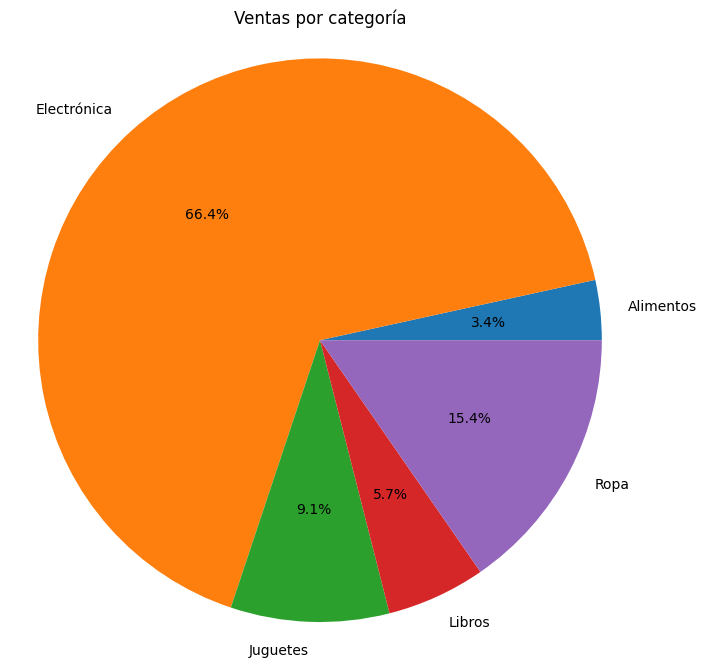

In [26]:
##Gráfico de torta
ventasPorCategorias = dataFrameFusionado.groupby('Producto')['Total Venta'].sum().reset_index()

plt.figure(figsize=(8,8))

plt.pie(ventasPorCategorias['Total Venta'], labels=ventasPorCategorias['Producto'], autopct='%1.1f%%') #Formato de porcentaje con un solo decimal
plt.title('Ventas por categoría')
plt.axis('equal')

Gráfico de Lineas
- Con el motivo de mostrar el eje x con los meses ordenados, se hizo lo siguiente:

In [ ]:
#Ordenando meses
ordenMeses = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
ventasPorMes = dataFrameFusionado.groupby(dataFrameFusionado['Fecha'].dt.month_name())['Total Venta'].sum().reset_index()
ventasPorMes['Fecha'] = pd.Categorical(ventasPorMes['Fecha'], categories=ordenMeses, ordered=True)
ventasPorMes = ventasPorMes.sort_values('Fecha')
print(ventasPorMes)

Una vez ordenado los meses fuimos capaces de configurar el plot.

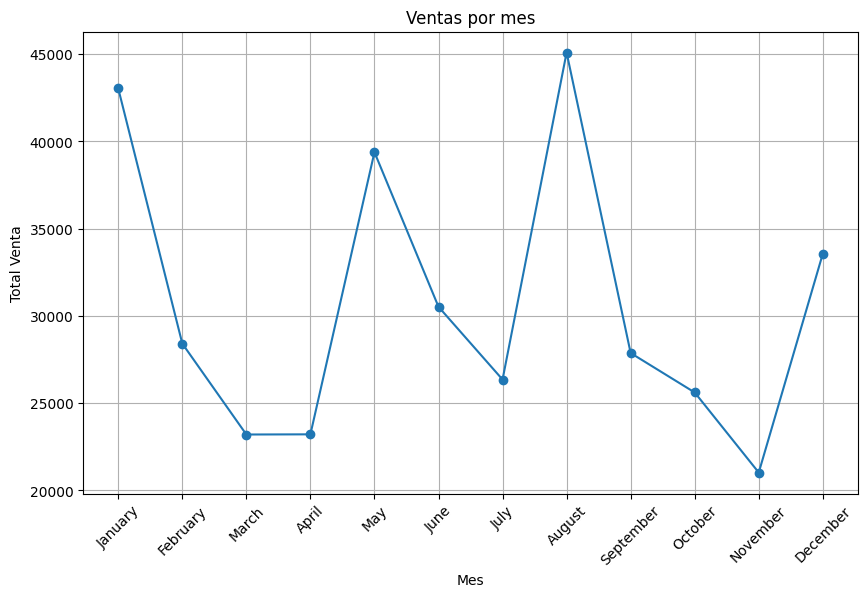

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(ventasPorMes['Fecha'], ventasPorMes['Total Venta'], marker='o')
plt.title('Ventas por mes')
plt.xlabel('Mes')
plt.ylabel('Total Venta')
plt.xticks(rotation=45)
plt.grid()
plt.show()  